In [ ]:
import pandas as pd 
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten,Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score

In [22]:
df = pd.read_csv('mnist_train.csv')
df.head(3)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


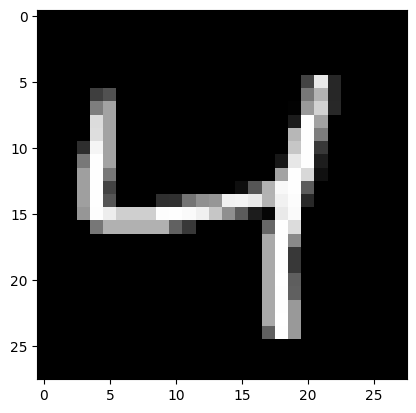

In [24]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[2,1:].values.reshape(28,28), cmap='gray')

In [25]:
X = df.drop('label', axis=1)
y = df['label']

In [26]:
x_tr,x_tst,y_tr,y_tst =train_test_split(X,y,test_size=0.2,random_state=44)


In [27]:
x_tr = x_tr / 255
x_tst = x_tst / 255

In [ ]:

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(32,activation = 'relu'),
    Dense(10, activation='softmax')
])

In [63]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(loss = 'sparse_categorical_crossentropy',optimizer = 'adam',metrics= ['accuracy'])

In [65]:
history = model.fit(x_tr,y_tr,epochs = 10,validation_split= 0.2)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9095 - loss: 0.3068 - val_accuracy: 0.9465 - val_loss: 0.1821
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9602 - loss: 0.1324 - val_accuracy: 0.9590 - val_loss: 0.1321
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9720 - loss: 0.0905 - val_accuracy: 0.9652 - val_loss: 0.1113
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9804 - loss: 0.0650 - val_accuracy: 0.9690 - val_loss: 0.1126
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9834 - loss: 0.0524 - val_accuracy: 0.9677 - val_loss: 0.1100
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9879 - loss: 0.0396 - val_accuracy: 0.9701 - val_loss: 0.1087
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9887 - loss: 0.0336 - val_accuracy: 0.9705 - val_loss: 0.1142
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9921 - loss: 0.0262 - 

In [67]:
y_pred_prob = model.predict(x_tst)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [68]:
import numpy as np

y_pred_labels = np.argmax(y_pred_prob, axis=1)

In [69]:
y_pred_labels

array([9, 2, 2, ..., 9, 2, 9], shape=(12000,))

In [70]:
accuracy_score(y_pred_labels,y_tst)

0.9735

In [71]:
confusion_matrix(y_pred_labels,y_tst)

array([[1137,    0,    1,    0,    2,    5,    3,    0,    8,    6],
       [   1, 1270,    3,    0,    4,    0,    0,    4,    1,    3],
       [   5,    6, 1165,   14,   10,    0,    2,    8,   10,    2],
       [   0,    1,   12, 1210,    0,   17,    1,    5,   14,   11],
       [   1,    0,    3,    0, 1163,    1,    0,    3,    3,   10],
       [   1,    0,    0,    6,    0, 1032,    3,    1,    5,    3],
       [   5,    2,    1,    1,    6,   10, 1174,    0,    9,    0],
       [   0,    1,    2,    2,    6,    0,    0, 1232,    0,    7],
       [   4,    5,    4,    6,    3,    6,    1,    3, 1178,    6],
       [   0,    0,    1,    5,    8,    3,    0,    6,    6, 1121]])

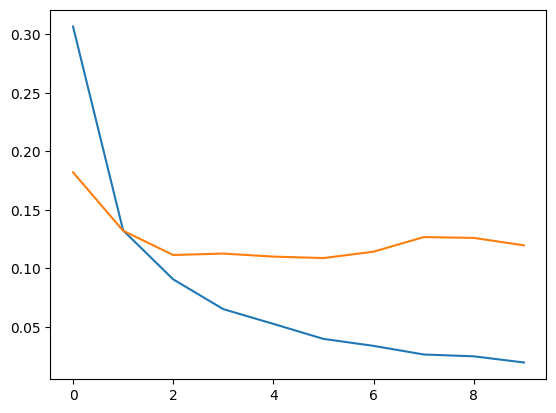

In [73]:
import matplotlib.pyplot as plt 
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

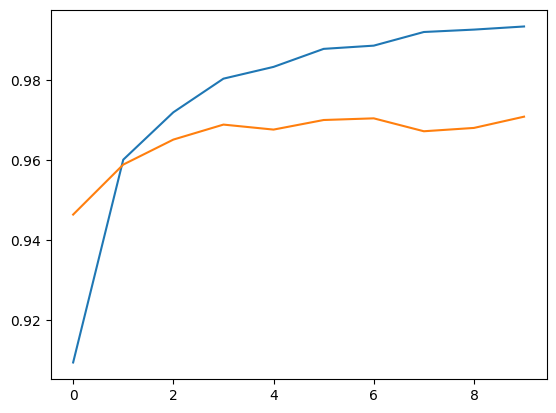

In [75]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [ ]:
df_test = pd.read_csv(r'mnist_test.csv')